<a href="https://colab.research.google.com/github/sepehriravani/explainable-predictive-maintenance/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Predictive Maintenance

## 01 — Data Exploration

This project aims to predict machine failures using operational
machine data and explain the factors associated with failure.

In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

In [ ]:
data = fetch_ucirepo(id=601)

In [ ]:
print(data)

{'data': {'ids':         UID Product ID
0         1     M14860
1         2     L47181
2         3     L47182
3         4     L47183
4         5     L47184
...     ...        ...
9995   9996     M24855
9996   9997     H39410
9997   9998     M24857
9998   9999     H39412
9999  10000     M24859

[10000 rows x 2 columns], 'features':      Type  Air temperature  Process temperature  Rotational speed  Torque  \
0       M            298.1                308.6              1551    42.8   
1       L            298.2                308.7              1408    46.3   
2       L            298.1                308.5              1498    49.4   
3       L            298.2                308.6              1433    39.5   
4       L            298.2                308.7              1408    40.0   
...   ...              ...                  ...               ...     ...   
9995    M            298.8                308.4              1604    29.5   
9996    H            298.9                308.4     

In [ ]:
data.metadata

{'uci_id': 601,
 'name': 'AI4I 2020 Predictive Maintenance Dataset',
 'repository_url': 'https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/601/data.csv',
 'abstract': 'The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset that reflects real predictive maintenance data encountered in industry.',
 'area': 'Computer Science',
 'tasks': ['Classification', 'Regression', 'Causal-Discovery'],
 'characteristics': ['Multivariate', 'Time-Series'],
 'num_instances': 10000,
 'num_features': 6,
 'feature_types': ['Real'],
 'demographics': [],
 'target_col': ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
 'index_col': ['UID', 'Product ID'],
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Wed Feb 14 2024',
 'dataset_doi': '10.24432/C5HS5C',
 'creators': [],
 'intro_paper': {'ID': 386,
  'type': 'NATIVE',
  'title': 'Explainab

In [ ]:
X = data.data.features
y = data.data.targets

In [ ]:
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [ ]:
y.head()

,Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [ ]:
target = y["Machine failure"]

In [ ]:
target.value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
target.value_counts(normalize = True) * 100

,proportion
Machine failure,
0,96.61
1,3.39


### Initial observation

The target variable is highly imbalanced. Most observations belong to
the non-failure class, while only a small percentage represent machine
failures. Therefore, accuracy alone may not be a reliable evaluation
metric for this problem.

In [ ]:
df = X.copy()
df["Machine failure"] = target

In [ ]:
df.shape

(10000, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


In [ ]:
df.isnull().sum()

,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed,0
Torque,0
Tool wear,0
Machine failure,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [ ]:
df["Type"].value_counts(normalize=True) * 100

,proportion
Type,
L,60.00
M,29.97
H,10.03


In [ ]:
df.groupby("Type")["Machine failure"].mean() * 100

,Machine failure
Type,
H,2.093719
L,3.916667
M,2.769436


### Machine type and failure

The failure rate is different across machine types. Type L has the
highest failure rate, while Type H has the lowest failure rate.

In [ ]:
df.groupby("Machine failure")[
    [
        "Air temperature",
        "Process temperature",
        "Rotational speed",
        "Torque",
        "Tool wear"
    ]
].mean().round(2)

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Machine failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


In [ ]:
failure_counts = df["Machine failure"].value_counts()
failure_counts

,count
Machine failure,
0,9661
1,339


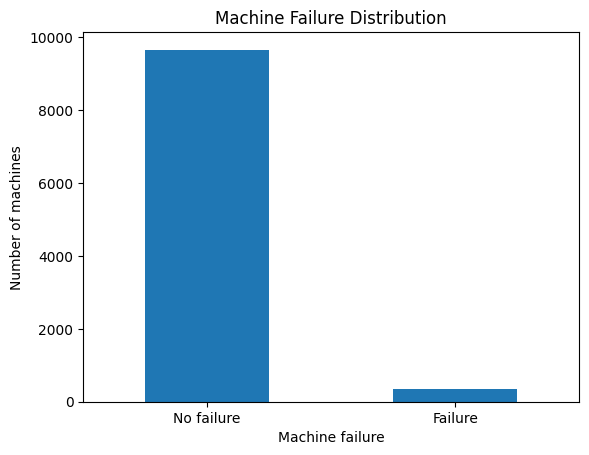

In [ ]:
failure_counts.plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine failure")
plt.ylabel("Number of machines")
plt.xticks([0, 1], ["No failure", "Failure"], rotation=0)
plt.show()


In [ ]:
correlations = df.corr(numeric_only=True)["Machine failure"]
correlations.sort_values(ascending=False)

,Machine failure
Machine failure,1.000000
Torque,0.191321
Tool wear,0.105448
Air temperature,0.082556
Process temperature,0.035946
Rotational speed,-0.044188


### Correlation with machine failure

Torque has the strongest positive correlation with machine failure,
followed by tool wear and air temperature. However, all correlations
are relatively weak, suggesting that failure may depend on a
combination of multiple features rather than one feature alone.

In [ ]:
feature_correlations = correlations.drop("Machine failure")

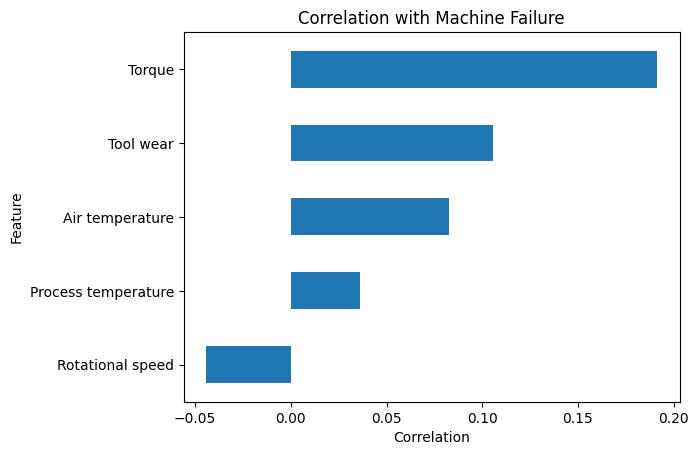

In [ ]:
feature_correlations.sort_values().plot(kind="barh")

plt.title("Correlation with Machine Failure")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

In [ ]:
healthy_torque = df[df["Machine failure"] == 0]["Torque"]
failed_torque = df[df["Machine failure"] == 1]["Torque"]

/tmp/ipykernel_1572/2794636145.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


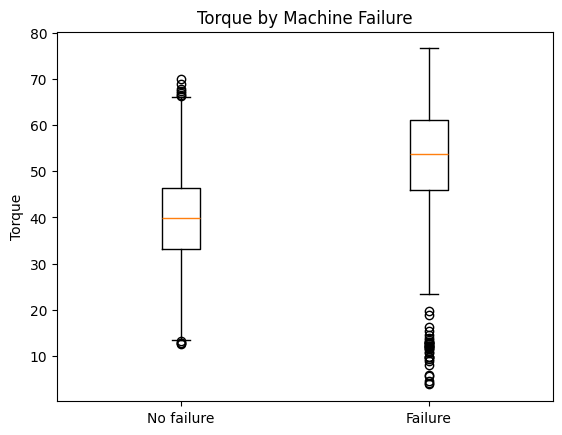

In [ ]:
plt.boxplot(
    [healthy_torque, failed_torque],
    labels=["No failure", "Failure"]
)

plt.title("Torque by Machine Failure")
plt.ylabel("Torque")
plt.show()

In [ ]:
healthy_tool_wear = df.loc[
    df["Machine failure"] == 0,
    "Tool wear"
]

failed_tool_wear = df.loc[
    df["Machine failure"] == 1,
    "Tool wear"
]

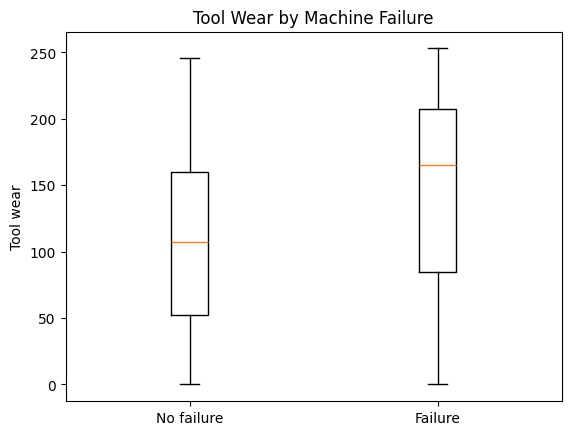

In [ ]:
plt.boxplot(
    [healthy_tool_wear, failed_tool_wear],
    tick_labels=["No failure", "Failure"]
)

plt.title("Tool Wear by Machine Failure")
plt.ylabel("Tool wear")
plt.show()

## Conclusion

The dataset contains 10,000 observations and has no missing values.

Machine failure is highly imbalanced, with only 339 failure cases.
Therefore, accuracy alone will not be sufficient for evaluating the model.

The initial analysis shows that failed machines generally have:

- higher torque
- higher tool wear
- slightly higher air temperature
- lower rotational speed

Torque has the strongest linear correlation with machine failure.
However, the correlations are relatively weak, which suggests that
failure may depend on a combination of multiple features.